In [1]:
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

In [2]:
#biblioteke
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [3]:
#uvoz funkcija za model i evaluaciju
from src.modeling import create_detector
from src.evaluation import evaluate_model

In [4]:
#putanje
PROCESSED_DIR = Path("data/processed")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = Path("models")

TRAIN_PATH = PROCESSED_DIR / "train.csv"
AUGMENTED_PATH = PROCESSED_DIR / "augmented_train.csv"
CHALLENGE_PATH = PROCESSED_DIR / "challenge_test.csv"

CHALLENGE_RESULTS_PATH = RESULTS_DIR / "challenge_metrics.csv"

In [5]:
#ucitavanje train podataka tj originalnog i augmentiranog train skupa
train_df = pd.read_csv(TRAIN_PATH)
augmented_train = pd.read_csv(AUGMENTED_PATH)

print("Original train:", len(train_df))
print("Augmented train:", len(augmented_train))


Original train: 31268
Augmented train: 29574


In [6]:
print("ORIGINAL TRAIN")
print(train_df["label"].value_counts().sort_index())

print("\nAUGMENTED TRAIN")
print(augmented_train["label"].value_counts().sort_index())

ORIGINAL TRAIN
label
0    16955
1    14313
Name: count, dtype: int64

AUGMENTED TRAIN
label
0    14411
1    15163
Name: count, dtype: int64


In [ ]:
#ne pokretati ponovno, treniranje baseline modela na originalnom train skupu
baseline_model = create_detector(
    random_state=42
)

baseline_model.fit(
    train_df["full_text"],
    train_df["label"]
)

print("Baseline model trained")

Baseline model trained


In [ ]:
#ne pokretati ponovno, treniranje augmented modela na originalnim i sintetickim podacima
augmented_model = create_detector(
    random_state=42
)

augmented_model.fit(
    augmented_train["full_text"],
    augmented_train["label"]
)

print("Augmented model trained.")

Augmented model trained.


In [ ]:
#ne pokretati ponovno, Spremanje istreniranih modela

joblib.dump(baseline_model, MODELS_DIR / "baseline_model.joblib")
joblib.dump(augmented_model, MODELS_DIR / "augmented_model.joblib")

print("Models saved.")

In [7]:
#ucitavanje challenge testa 
challenge_df = pd.read_csv(
    CHALLENGE_PATH
)

print("Challenge test:",len(challenge_df))

print("\nVrste primjera:")

print(challenge_df["manipulation_type"].value_counts())

print("\nLabele:")

print(challenge_df["label"].value_counts())

print(challenge_df["generator_model"].value_counts())

Challenge test: 800

Vrste primjera:
manipulation_type
original       200
fact_change    200
clickbait      200
tone_shift     200
Name: count, dtype: int64

Labele:
label
1    600
0    200
Name: count, dtype: int64
generator_model
gemini-3.5-flash    600
none                200
Name: count, dtype: int64


In [8]:
#funkcija za izradu challenge testa za pojedinu vrstu manipulacije
# Za svaki tip manipulacije uzima manipulirane vijesti i njihove originalne verzije
def create_challenge_subset(challenge_df, manipulation_type):

    synthetic_subset = challenge_df[
            challenge_df["manipulation_type"] == manipulation_type
        ].copy()
    
    source_ids = synthetic_subset["source_id"].unique()
    
    real_subset = challenge_df[
        (challenge_df["manipulation_type"] == "original")
        &(challenge_df["source_id"].isin(source_ids))
        ].copy()
    
    subset = pd.concat(
        [real_subset, synthetic_subset], ignore_index=True
    )

    return subset

In [9]:
#3 zasebna challenge testa
challenge_tests = {
    "fact_change": create_challenge_subset(
        challenge_df,
        "fact_change"
    ),

    "clickbait": create_challenge_subset(
        challenge_df,
        "clickbait"
    ),

    "tone_shift": create_challenge_subset(
        challenge_df,
        "tone_shift"
    )
}

In [10]:
# provjera velicine i raspodjele svakog challenge testa

for name, test_set in challenge_tests.items():

    print("\n", name)

    print("Broj primjera:", len(test_set))

    print(test_set["label"].value_counts().sort_index())


 fact_change
Broj primjera: 400
label
0    200
1    200
Name: count, dtype: int64

 clickbait
Broj primjera: 400
label
0    200
1    200
Name: count, dtype: int64

 tone_shift
Broj primjera: 400
label
0    200
1    200
Name: count, dtype: int64


In [11]:
#ucitavanje spremljenih modela da preskocim .fit
baseline_model = joblib.load(
    MODELS_DIR
    / "baseline_model.joblib"
)

augmented_model = joblib.load(
    MODELS_DIR
    / "augmented_model.joblib"
)

print(
    "Models loaded."
)

Models loaded.


In [12]:
#modeli koji se usporeduju

models = {
    "Baseline": baseline_model,
    "Augmented": augmented_model
}

In [13]:
# evaluacija oba modela na sve tri vrste manipulacije

challenge_results = []

for manipulation_type, test_set in challenge_tests.items():

    for model_name, model in models.items():

        metrics = evaluate_model(
            model=model,
            X_test=test_set["full_text"],
            y_test=test_set["label"],
            model_name=model_name
        )

        metrics["manipulation_type"] = manipulation_type

        challenge_results.append(
            metrics
        )

In [14]:
# rezultati evaluacije

challenge_metrics = pd.DataFrame(challenge_results)

challenge_metrics

,model,accuracy,precision,recall,f1,manipulation_type
0,Baseline,0.5000,0.500000,0.005,0.009901,fact_change
1,Augmented,0.5025,0.666667,0.010,0.019704,fact_change
2,Baseline,0.5000,0.500000,0.005,0.009901,clickbait
3,Augmented,0.7475,0.990099,0.500,0.664452,clickbait
4,Baseline,0.5900,0.973684,0.185,0.310924,tone_shift
5,Augmented,0.9700,0.994737,0.945,0.969231,tone_shift


In [15]:
# Usporedba F1 rezultata u postotcima

f1_comparison = challenge_metrics.pivot(
    index="manipulation_type",
    columns="model",
    values="f1"
) * 100

f1_comparison["Improvement"] = (
    f1_comparison["Augmented"] - f1_comparison["Baseline"]
)

f1_comparison = f1_comparison[
    ["Baseline", "Augmented", "Improvement"]
].round(2)

f1_comparison.style.format({
    "Baseline": "{:.2f}%",
    "Augmented": "{:.2f}%",
    "Improvement": "{:+.2f}%"
})


model,Baseline,Augmented,Improvement
manipulation_type,,,
clickbait,0.99%,66.45%,+65.46%
fact_change,0.99%,1.97%,+0.98%
tone_shift,31.09%,96.92%,+65.83%


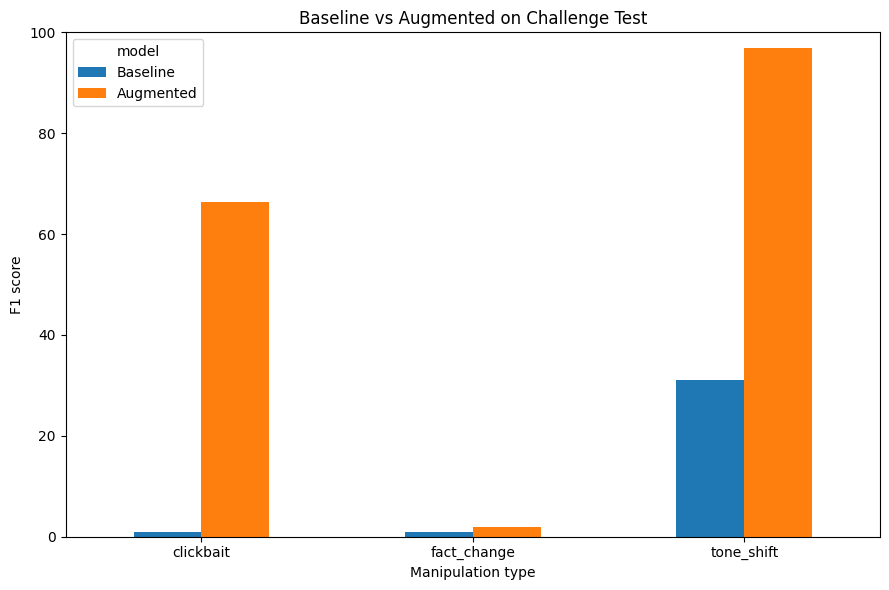

In [16]:
# graficka usporedba F1 rezultata

f1_comparison[
    ["Baseline", "Augmented"]
].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Baseline vs Augmented on Challenge Test")
plt.xlabel("Manipulation type")
plt.ylabel("F1 score")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "challenge_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
#spremanje rezultata evaluacije 
challenge_metrics.to_csv(
    CHALLENGE_RESULTS_PATH,
    index=False
)

print("Challenge metrics saved.")

Challenge metrics saved.
